# 5 - Psychological & Affective Landscape

This notebook examines psychological traits and affective states across waves.

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde, chi2_contingency
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from typing import Optional, Tuple


%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import (
    get_data_root, get_pkl_paths,
    COLORS, WAVE_LABELS, WAVE_KEYS, WAVE_TO_DIR, SHARED_LABELS, set_paper_style,
)

DATA_ROOT = get_data_root()
FILES     = get_pkl_paths(DATA_ROOT)
set_paper_style()


2026-03-31 17:45:34.658100: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 17:45:34.659210: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 17:45:34.679506: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-31 17:45:34.679968: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 17:45:35.041480: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

## Load data

In [2]:
from utils import (
    load_wave_esm_userinfo,
    load_and_attach, extract_gender,
    get_label_series,
)

In [3]:
df_X_1 = load_and_attach(FILES["D-1"], "D-1")
df_X_2 = load_and_attach(FILES["D-2"], "D-2")
df_X_3 = load_and_attach(FILES["D-3"], "D-3")

for df_X in [df_X_1, df_X_2, df_X_3]:
    # Consolidate gender using shared helper
    df_X["PIF#gender"] = extract_gender(df_X)
    
    # Consolidate age into a single numeric column
    if "PIF#age" in df_X.columns:
        df_X["PIF#age"] = df_X.filter(regex="(?i)PIF#age").bfill(axis=1).iloc[:, 0]

df_X_combined = pd.concat(
    [df_X_1.assign(__src="D1"),
     df_X_2.assign(__src="D2"),
     df_X_3.assign(__src="D3")],
    axis=0, join="inner", ignore_index=True
)

## Data processing

In [4]:
esm_by_wave, userinfo_by_wave, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=True,
    include_study_day=True,
)

def user_series(wave_key: str, trait_col: str) -> pd.Series:
    """Return per-user mean for a given wave and column (ESM → UserInfo fallback)."""
    esm_df = esm_by_wave.get(wave_key, pd.DataFrame())
    if not esm_df.empty and trait_col in esm_df.columns:
        return esm_df.groupby("Pcode")[trait_col].mean()
    ui_df = userinfo_by_wave.get(wave_key, pd.DataFrame())
    if not ui_df.empty and trait_col in ui_df.columns:
        return ui_df[trait_col]
    return pd.Series(dtype=float)

---
## Visuals

### PSS-10 distribution
Insight: Compares perceived stress baselines across waves.

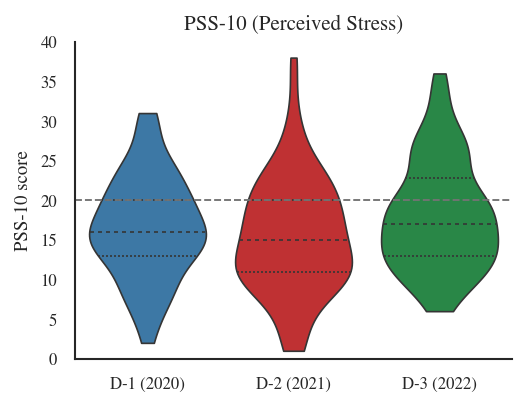

In [5]:
pss_by_wave = {k: user_series(k, "PSS10") for k in WAVE_KEYS}
pss_df = (
    pd.DataFrame(
        [(wave, float(v)) for wave, arr in pss_by_wave.items() for v in arr],
        columns=["Wave", "PSS10"],
    )
    if any(len(v) > 0 for v in pss_by_wave.values())
    else pd.DataFrame(columns=["Wave", "PSS10"])
)
if not pss_df.empty:
    pss_df["Wave"] = pd.Categorical(pss_df["Wave"], categories=WAVE_KEYS, ordered=True)

fig, ax = plt.subplots(figsize=(3.4, 2.6), constrained_layout=True)
if pss_df.empty:
    ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
    ax.set_axis_off()
else:
    sns.violinplot(
        data=pss_df,
        x="Wave",
        y="PSS10",
        hue="Wave",
        order=WAVE_KEYS,
        palette=COLORS,
        inner="quartile",
        linewidth=0.8,
        cut=0,
        dodge=False,
        legend=False,
        ax=ax,
    )
    ax.axhline(20, color="0.45", ls="--", lw=0.9)
    if ax.get_legend():
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("PSS-10 score")
    ax.set_title("PSS-10 (Perceived Stress)")
    ax.set_xticks(range(len(WAVE_KEYS)))
    ax.set_xticklabels(WAVE_LABELS)
    ax.set_ylim(0, 40)
plt.show()

---
### GHQ-12 distribution
Insight: Compares general mental health baselines across waves.

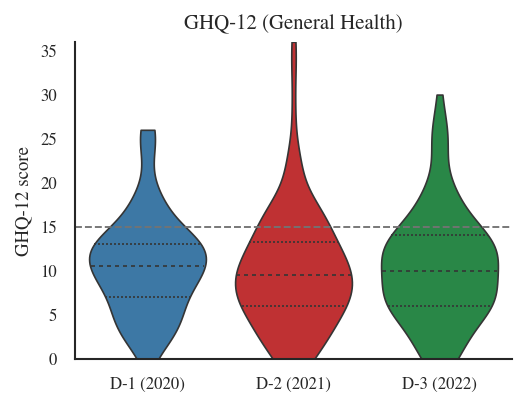

In [6]:
ghq_by_wave = {k: user_series(k, "GHQ12") for k in WAVE_KEYS}
ghq_df = (
    pd.DataFrame(
        [(wave, float(v)) for wave, arr in ghq_by_wave.items() for v in arr],
        columns=["Wave", "GHQ12"],
    )
    if any(len(v) > 0 for v in ghq_by_wave.values())
    else pd.DataFrame(columns=["Wave", "GHQ12"])
)
if not ghq_df.empty:
    ghq_df["Wave"] = pd.Categorical(ghq_df["Wave"], categories=WAVE_KEYS, ordered=True)

fig, ax = plt.subplots(figsize=(3.4, 2.6), constrained_layout=True)
if ghq_df.empty:
    ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
    ax.set_axis_off()
else:
    sns.violinplot(
        data=ghq_df,
        x="Wave",
        y="GHQ12",
        hue="Wave",
        order=WAVE_KEYS,
        palette=COLORS,
        inner="quartile",
        linewidth=0.8,
        cut=0,
        dodge=False,
        legend=False,
        ax=ax,
    )
    ax.axhline(15, color="0.45", ls="--", lw=0.9)
    if ax.get_legend():
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("GHQ-12 score")
    ax.set_title("GHQ-12 (General Health)")
    ax.set_xticks(range(len(WAVE_KEYS)))
    ax.set_xticklabels(WAVE_LABELS)
    ax.set_ylim(0, 36)
plt.show()

### Big Five Trait Profile by Wave

This radar chart compares average Big Five trait profiles across the three waves.

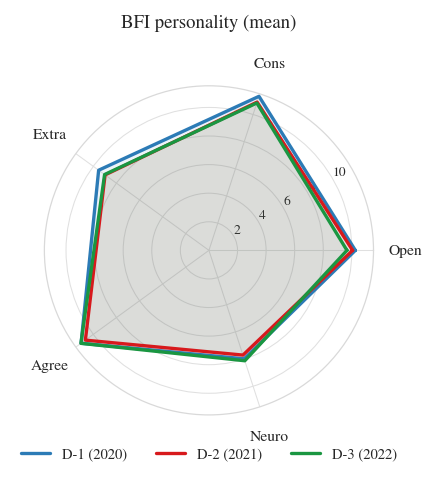

In [7]:
traits = ["Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism"]
bfi_means: dict[str, list[float]] = {}
for wave in WAVE_KEYS:
    uinfo = userinfo_by_wave.get(wave, pd.DataFrame())
    if not uinfo.empty and all(col in uinfo.columns for col in traits):
        vals = uinfo[traits].mean(numeric_only=True).to_list()
        bfi_means[wave] = [float(v) for v in vals]
    else:
        bfi_means[wave] = []

fig, ax = plt.subplots(figsize=(3.6, 3.1), subplot_kw={"polar": True}, constrained_layout=True)
if not any(len(v) == len(traits) for v in bfi_means.values()):
    ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, color="gray")
    ax.set_axis_off()
    plt.show()
else:
    n_traits = len(traits)
    angles = np.linspace(0, 2 * np.pi, n_traits, endpoint=False).tolist()
    angles += angles[:1]

    for wave in WAVE_KEYS:
        vals = bfi_means.get(wave, [])
        if len(vals) != n_traits:
            continue
        vals_closed = vals + vals[:1]
        ax.plot(angles, vals_closed, color=COLORS[wave], lw=1.6, label=WAVE_LABELS[WAVE_KEYS.index(wave)])
        ax.fill(angles, vals_closed, color=COLORS[wave], alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(["Open", "Cons", "Extra", "Agree", "Neuro"], fontsize=7.5)
    ax.set_rlabel_position(30)
    ax.tick_params(axis="y", labelsize=6.5)
    ax.grid(color="0.88", lw=0.5)
    ax.spines["polar"].set_color("0.85")
    ax.spines["polar"].set_linewidth(0.6)
    ax.set_title("BFI personality (mean)", fontsize=9, pad=14)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=7, frameon=False)
    plt.show()

In [8]:
# ── Common feature columns across all three waves ─────────────────────────────
_meta_cols = {"META#dataset", "PIF#participantID", "PIF#stress_label",
              "PIF#time_offset", "PIF#timestamp", "__src"}
_common_cols = (
    set(df_X_combined[df_X_combined["META#dataset"] == "D-1"].columns)
    & set(df_X_combined[df_X_combined["META#dataset"] == "D-2"].columns)
    & set(df_X_combined[df_X_combined["META#dataset"] == "D-3"].columns)
)
common_feature_cols = list(_common_cols - _meta_cols)
numeric_common = [
    c for c in common_feature_cols
    if df_X_combined[c].dtype in ["float64", "int64", "float32", "int32"]
]

d1_data = df_X_combined[df_X_combined["META#dataset"] == "D-1"]
d2_data = df_X_combined[df_X_combined["META#dataset"] == "D-2"]
d3_data = df_X_combined[df_X_combined["META#dataset"] == "D-3"]

---
### Covariate Shift: P(X) differs across waves

In [9]:
# ── 3. PCA VISUALIZATION (PER-USER MEANS) ─────────────────────────────────
# Compute per-user feature means
user_means = df_X_combined.groupby(['PIF#participantID', 'META#dataset'])[numeric_common].mean()
user_means = user_means.reset_index()
# Prepare data for PCA
X = user_means[numeric_common].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

### PCA Scatter of Participant Profiles

This scatter plot compares PCA-reduced per-user sensor features across datasets.

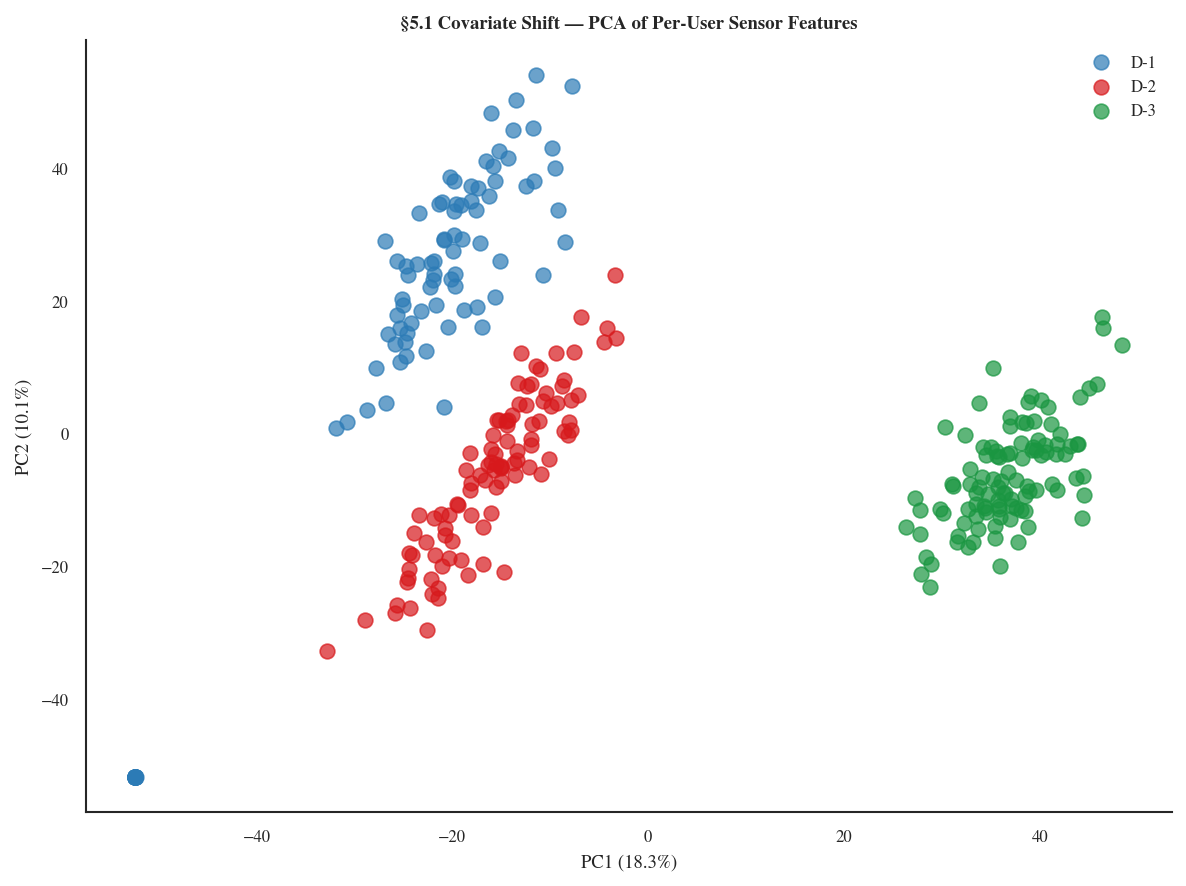

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for ds, color in COLORS.items():
    mask = user_means["META#dataset"] == ds
    xs, ys = X_pca[mask, 0], X_pca[mask, 1]
    ax.scatter(xs, ys, c=color, label=ds, alpha=0.7, s=50)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)
ax.set_title("§5.1 Covariate Shift — PCA of Per-User Sensor Features", fontsize=9, fontweight="bold")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### UMAP: Per-User Feature Means

This projection view shows how participant profiles cluster and separate across datasets in 2D space.

/home/iclab/miniconda/envs/sci-data/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


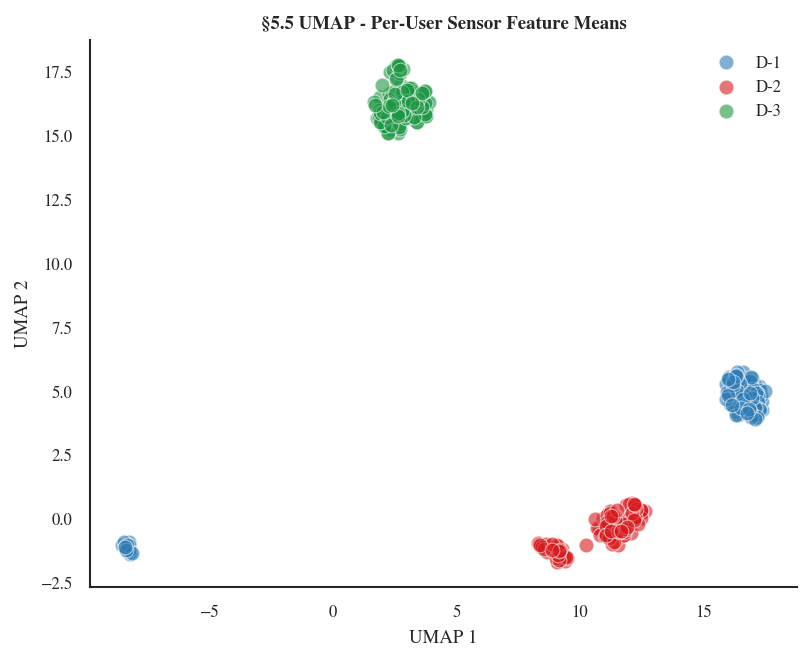

In [12]:
# ── §5.5 UMAP: Per-User Feature Means ────────────────────────────────────────
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for ds, color in COLORS.items():
    mask = user_means["META#dataset"] == ds
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, label=ds, alpha=0.6, s=50, edgecolors="white", linewidth=0.5)
ax.set_xlabel("UMAP 1", fontsize=9)
ax.set_ylabel("UMAP 2", fontsize=9)
ax.set_title("§5.5 UMAP - Per-User Sensor Feature Means", fontsize=9, fontweight="bold")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### t-SNE: Per-User Feature Means

This projection view shows how participant profiles cluster and separate across datasets in 2D space.

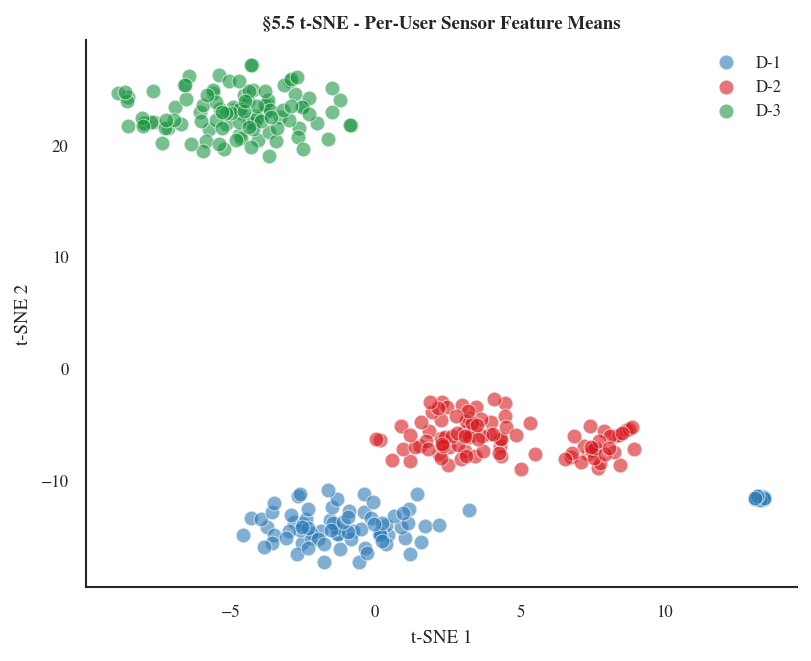

In [13]:
# ── §5.5 t-SNE: Per-User Feature Means ───────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto",
            init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for ds, color in COLORS.items():
    mask = user_means["META#dataset"] == ds
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=ds, alpha=0.6, s=50, edgecolors="white", linewidth=0.5)
ax.set_xlabel("t-SNE 1", fontsize=9)
ax.set_ylabel("t-SNE 2", fontsize=9)
ax.set_title("§5.5 t-SNE - Per-User Sensor Feature Means", fontsize=9, fontweight="bold")
ax.legend(fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Feature Distribution Drift Across Waves

This section compares how selected sensor feature distributions shift across waves.

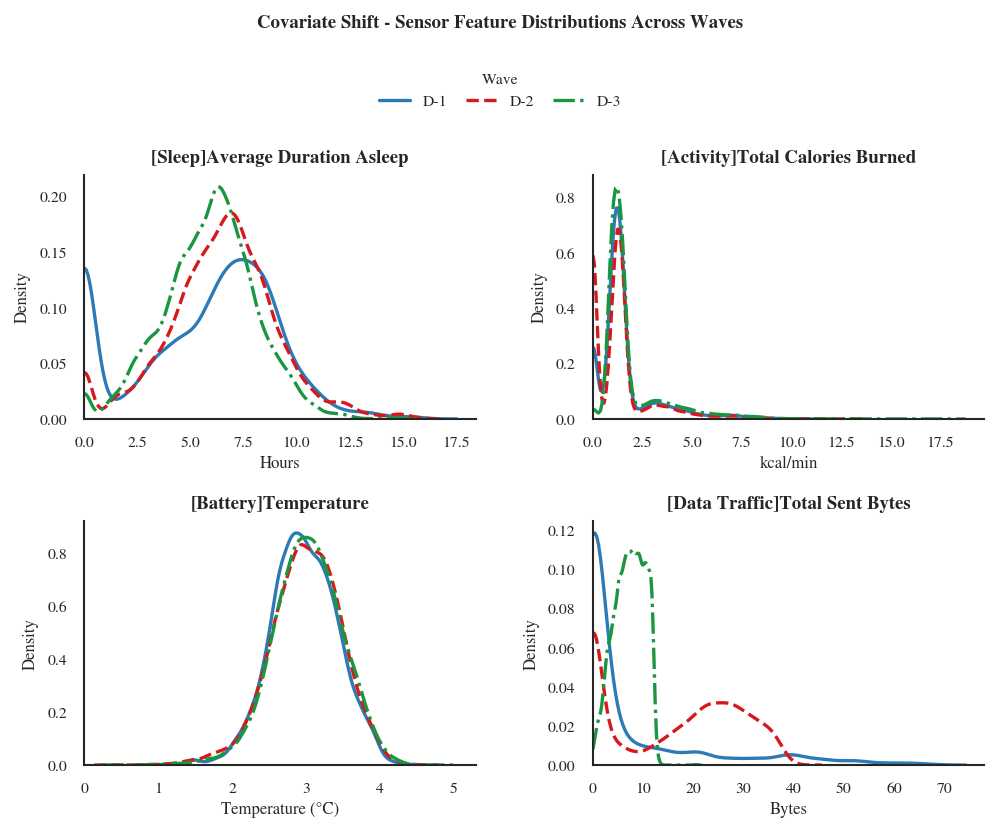

In [67]:
# ── Feature configuration ─────────────────────────────────────────────────────────────────────────────
top_features = [
    "Sleep#Duration",
    "Fitbitcalorie#VAL",
    "BAT_TMP#VAL",
    "DATA_SNT#TSC#YesterdayNight",
]
 
feature_titles = {
    "Sleep#Duration"              : ("[Sleep]",        "Average Duration Asleep"),
    "Fitbitcalorie#VAL"           : ("[Activity]",     "Total Calories Burned"),
    "BAT_TMP#VAL"                 : ("[Battery]",      "Temperature"),
    "DATA_SNT#TSC#YesterdayNight" : ("[Data Traffic]", "Total Sent Bytes"),
}
 
feature_units = {
    "Sleep#Duration"              : "Hours",
    "Fitbitcalorie#VAL"           : "kcal/min",
    "BAT_TMP#VAL"                 : "Temperature (°C)",
    "DATA_SNT#TSC#YesterdayNight" : "Bytes",
}
 
_LINESTYLES = {"D-1": "-", "D-2": "--", "D-3": "-."}
 
 
def _prepare_vals(feature, ds_df):
    """Apply per-feature unit conversion and cleaning."""
    vals = ds_df[feature].dropna()
    if feature == "Sleep#Duration":
        vals = vals[vals >= 0] / 3600.0          # seconds → hours
    elif feature == "BAT_TMP#VAL":
        vals = vals[vals > 0] / 10.0             # deci-°C → °C
    else:
        vals = vals[vals >= 0]
    return vals
 
 
fig, axes = plt.subplots(2, 2, figsize=(6.75, 5.0))
axes_flat = axes.ravel()
 
for ax, feature in zip(axes_flat, top_features):
    for ds in WAVE_KEYS:
        ds_df = df_X_combined[df_X_combined["META#dataset"] == ds]
        vals  = _prepare_vals(feature, ds_df)
        if len(vals) < 5:
            continue
        sns.kdeplot(
            vals, ax=ax, color=COLORS[ds], linestyle=_LINESTYLES[ds],
            linewidth=1.6, label=ds, common_norm=False, clip=(0, None),
        )
 
    tag, subtitle = feature_titles.get(feature, (f"[{feature}]", ""))
    ax.set_title(f"{tag}{subtitle}", fontsize=9, fontweight="bold", loc="center", pad=6)
    ax.set_xlabel(feature_units.get(feature, ""), fontsize=8, labelpad=3)
    ax.set_ylabel("Density", fontsize=8)
    ax.set_xlim(left=0)
    ax.tick_params(labelsize=7.5)
    if ax.get_legend():
        ax.get_legend().remove()
 
for ax in axes_flat[len(top_features):]:
    ax.set_axis_off()
 
legend_handles = [
    Line2D([0], [0], color=COLORS[w], linestyle=_LINESTYLES[w], linewidth=1.6, label=w)
    for w in WAVE_KEYS
]
fig.legend(
    handles=legend_handles, title="Wave", title_fontsize=7.5, fontsize=7.5,
    loc="upper center", ncol=len(WAVE_KEYS), bbox_to_anchor=(0.5, 1.04),
    frameon=False, handlelength=2.0, columnspacing=1.2,
)
fig.suptitle(
    "Covariate Shift - Sensor Feature Distributions Across Waves",
    fontsize=9, fontweight="bold", y=1.10,
)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(hspace=0.42, wspace=0.30)
plt.show()

### Concept Shift Line Charts: Feature vs. % High Label

For each of three sensor features, participants are binned into Low / Medium / High using *global* tertiles (computed across all three datasets combined).

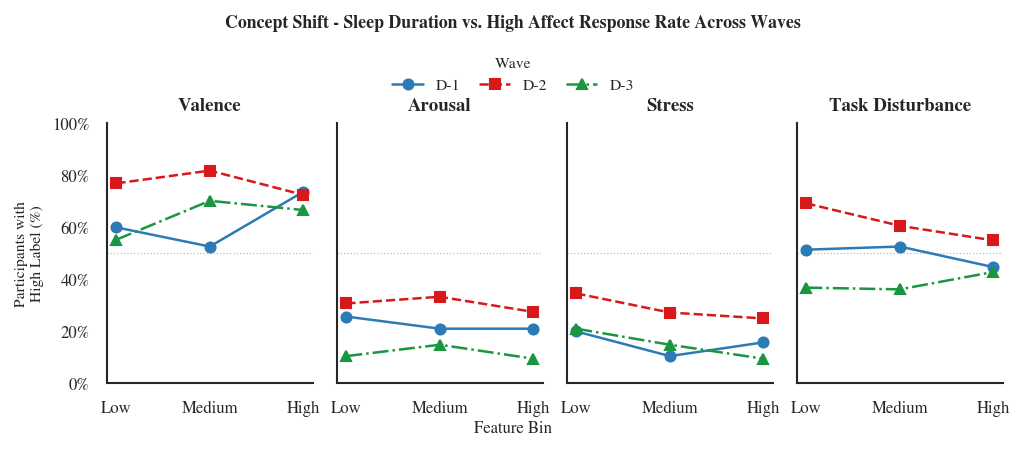

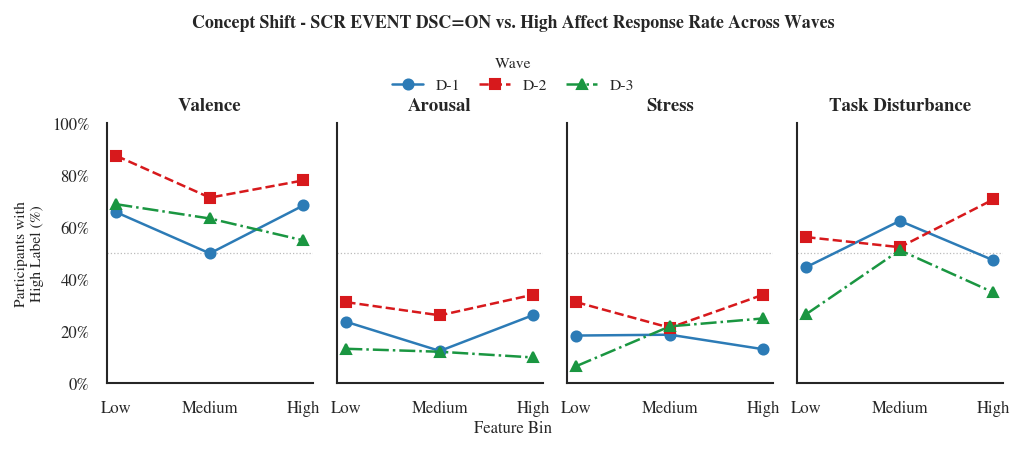

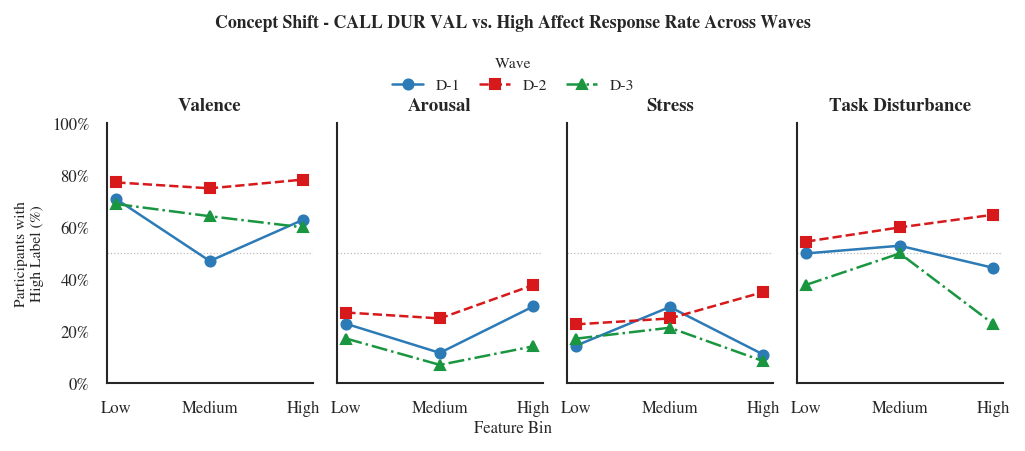

In [ ]:
# ── Visual K: Concept Shift Line Charts — Feature Tertiles vs. % High Label ──
# For each feature: bin participants by global tertiles, plot % with high ESM
# label per wave. Diverging/crossing lines = concept shift.
_cs_features = [
    "Sleep#Duration",
    "SCR_EVENT#DSC=ON",
    "CALL_DUR#VAL",
]
_BIN_LABELS  = ["Low", "Medium", "High"]
_LINESTYLES  = {"D-1": "-", "D-2": "--", "D-3": "-."}
_MARKERS     = {"D-1": "o", "D-2": "s", "D-3": "^"}

for _feature in _cs_features:
    if _feature not in df_X_combined.columns:
        print(f"  Skipping {_feature!r} — column not found in df_X_combined")
        continue

    feat_df = (
        df_X_combined[["META#dataset", "PIF#participantID", _feature]]
        .dropna()
        .groupby(["META#dataset", "PIF#participantID"])[_feature]
        .mean()
        .reset_index()
        .rename(columns={"META#dataset": "Wave", "PIF#participantID": "Pcode", _feature: "feat_val"})
    )

    q33, q67 = feat_df["feat_val"].quantile([1 / 3, 2 / 3])
    feat_df["bin"] = pd.cut(
        feat_df["feat_val"],
        bins=[-np.inf, q33, q67, np.inf],
        labels=_BIN_LABELS,
    )

    fig, axes = plt.subplots(1, 4, figsize=(6.75, 2.4), sharey=True)
    fig.subplots_adjust(wspace=0.18)

    for ax_i, (ax, lbl) in enumerate(zip(axes, SHARED_LABELS)):
        for wk in WAVE_KEYS:
            esm_wk = esm_by_wave[wk]
            if lbl not in esm_wk.columns:
                continue

            lbl_per_person = (
                esm_wk[["Pcode", lbl]]
                .dropna()
                .groupby("Pcode")[lbl]
                .median()
                .reset_index()
                .rename(columns={lbl: "lbl_score"})
            )
            lbl_per_person["binary"] = (lbl_per_person["lbl_score"] >= 1).astype(int)

            merged = feat_df[feat_df["Wave"] == wk].merge(
                lbl_per_person[["Pcode", "binary"]],
                on="Pcode", how="inner",
            )
            if merged.empty:
                continue

            pct = merged.groupby("bin", observed=True)["binary"].mean() * 100
            pct = pct.reindex(_BIN_LABELS)

            ax.plot(
                _BIN_LABELS, pct.values,
                color=COLORS[wk], ls=_LINESTYLES[wk], marker=_MARKERS[wk],
                label=wk if ax_i == 0 else "_nolegend_",
            )

        ax.axhline(50, color="#BBBBBB", lw=0.6, ls=":", zorder=1)
        ax.set_title(lbl, fontsize=9, fontweight="bold", pad=6)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(20))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

        if ax_i == 0:
            ax.set_ylabel("Participants with\nHigh Label (%)", fontsize=7.5)
        else:
            ax.tick_params(axis="y", labelleft=False)

    fig.text(0.5, -0.02, "Feature Bin", ha="center", fontsize=8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        bbox_to_anchor=(0.5, 1.06), loc="upper center",
        frameon=False, title="Wave", fontsize=7.5, title_fontsize=7.5,
        ncol=3, handlelength=2.0, columnspacing=1.2,
    )

    feature_display_name = _feature.replace("#", " ").replace("_", " ")
    fig.suptitle(
        f"Concept Shift - {feature_display_name} vs. High Affect Response Rate Across Waves",
        fontsize=8.5, fontweight="bold", y=1.14,
    )

    plt.tight_layout(pad=0.4)
    plt.show()

---
### Conditional Shift: P(X|Y) differs across waves

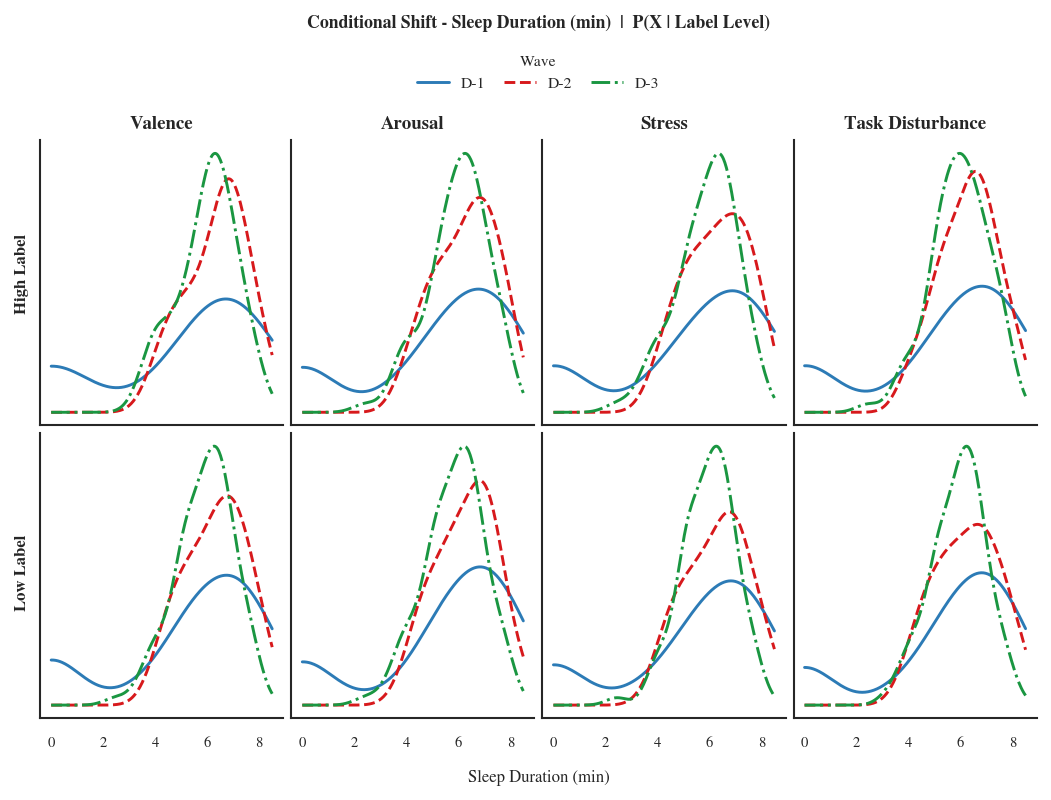

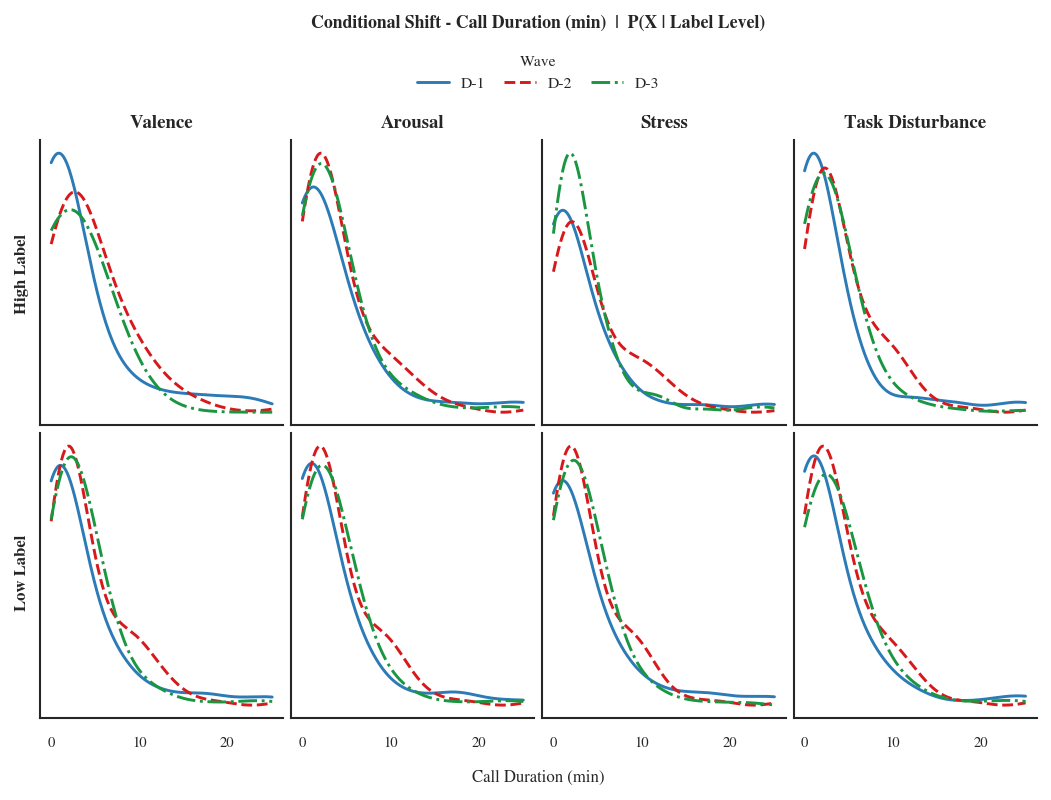

In [12]:
def _split_label_groups(
    lbl: str,
    esm_by_wave: dict,
    wave_keys: list,
) -> Optional[Tuple[set, set]]:
    """
    Split participants into High / Low groups based on their median label score
    pooled across all waves. Returns (high_pcodes, low_pcodes) or None if no data.
    """
    all_scores = []
    for wk in wave_keys:
        esm_wk = esm_by_wave[wk]
        if lbl not in esm_wk.columns:
            continue
        per_person = (
            esm_wk[["Pcode", lbl]]
            .dropna()
            .groupby("Pcode")[lbl]
            .median()
            .reset_index()
            .rename(columns={lbl: "lbl_score"})
        )
        per_person["Wave"] = wk
        all_scores.append(per_person)

    if not all_scores:
        return None

    all_df = pd.concat(all_scores, ignore_index=True)
    global_median = all_df["lbl_score"].median()
    high = set(all_df.loc[all_df["lbl_score"] >  global_median, "Pcode"])
    low  = set(all_df.loc[all_df["lbl_score"] <= global_median, "Pcode"])
    return high, low


_COND_FEATURES = [
    "Sleep#Duration",
    # "Fitbitcalorie#VAL",
    # "SCR_EVENT#DSC=ON",
    "CALL_DUR#VAL",
]
_FEATURE_DISPLAY = {
    "Sleep#Duration": "Sleep Duration (min)",
    "CALL_DUR#VAL":   "Call Duration (min)",
}
_UNIT_CONVERSIONS = {
    "Sleep#Duration": 3600,  # raw → minutes
    "CALL_DUR#VAL":   60,    # raw → minutes
}
_COND_LINESTYLES = {"D-1": "-", "D-2": "--", "D-3": "-."}


for _feature in _COND_FEATURES:
    if _feature not in df_X_combined.columns:
        print(f"  Skipping {_feature!r} — column not found")
        continue

    feat_df = (
        df_X_combined[["META#dataset", "PIF#participantID", _feature]]
        .dropna()
        .groupby(["META#dataset", "PIF#participantID"])[_feature]
        .mean()
        .reset_index()
        .rename(columns={"META#dataset": "Wave", "PIF#participantID": "Pcode", _feature: "feat_val"})
    )
    feat_df["feat_val"] /= _UNIT_CONVERSIONS.get(_feature, 1)

    x_lo   = feat_df["feat_val"].quantile(0.02)
    x_hi   = feat_df["feat_val"].quantile(0.98)
    x_grid = np.linspace(x_lo, x_hi, 300)

    fig, axes = plt.subplots(2, 4, figsize=(6.75, 4.5), sharex=True, sharey=False)
    fig.subplots_adjust(hspace=0.35, wspace=0.18)

    first_legend_ax = None

    for ax_i, (ax_row_high, ax_row_low, lbl) in enumerate(zip(axes[0], axes[1], SHARED_LABELS)):
        groups = _split_label_groups(lbl, esm_by_wave, WAVE_KEYS)
        if groups is None:
            continue
        high_pcodes, low_pcodes = groups

        for row_i, (ax, pcode_set) in enumerate([
            (ax_row_high, high_pcodes),
            (ax_row_low,  low_pcodes),
        ]):
            for wk in WAVE_KEYS:
                wave_feat = feat_df[(feat_df["Wave"] == wk) & feat_df["Pcode"].isin(pcode_set)]["feat_val"].dropna().values

                if len(wave_feat) < 5:
                    continue

                try:
                    y_vals = gaussian_kde(wave_feat, bw_method="scott")(x_grid)
                    show_label = (row_i == 0 and ax_i == 0)
                    ax.plot(
                        x_grid,
                        y_vals,
                        color=COLORS[wk],
                        ls=_COND_LINESTYLES[wk],
                        lw=1.4,
                        label=wk if show_label else "_nolegend_",
                    )
                    if show_label:
                        first_legend_ax = ax
                except Exception:
                    pass

            ax.spines[["top", "right"]].set_visible(False)
            ax.set_yticks([])
            ax.tick_params(labelsize=7)
            if row_i == 0:
                ax.set_title(lbl, fontsize=9, fontweight="bold", pad=6)

    for row_i, row_label in enumerate(["High Label", "Low Label"]):
        mid_y = (axes[row_i, 0].get_position().y0 + axes[row_i, 0].get_position().y1) / 2
        fig.text(-0.01, mid_y, row_label, ha="center", va="center", fontsize=8, fontweight="bold", rotation=90)

    feat_display = _FEATURE_DISPLAY.get(_feature, _feature)
    fig.text(0.5, -0.03, feat_display, ha="center", va="center", fontsize=8)

    if first_legend_ax is not None:
        handles, labels_ = first_legend_ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels_,
            bbox_to_anchor=(0.5, 1.06),
            loc="upper center",
            frameon=False,
            title="Wave",
            fontsize=7.5,
            title_fontsize=7.5,
            ncol=3,
            handlelength=2.0,
            columnspacing=1.2,
        )

    fig.suptitle(f"Conditional Shift - {feat_display}  |  P(X | Label Level)", fontsize=8.5, fontweight="bold", y=1.10)
    plt.tight_layout(pad=0.4)
    plt.show()

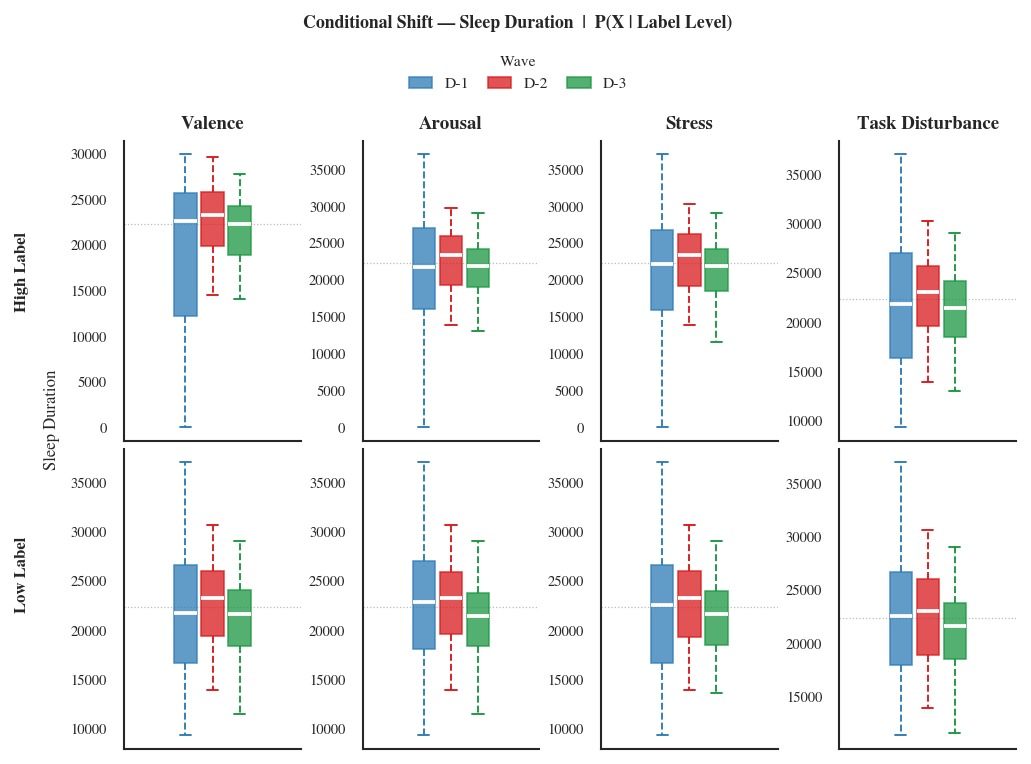

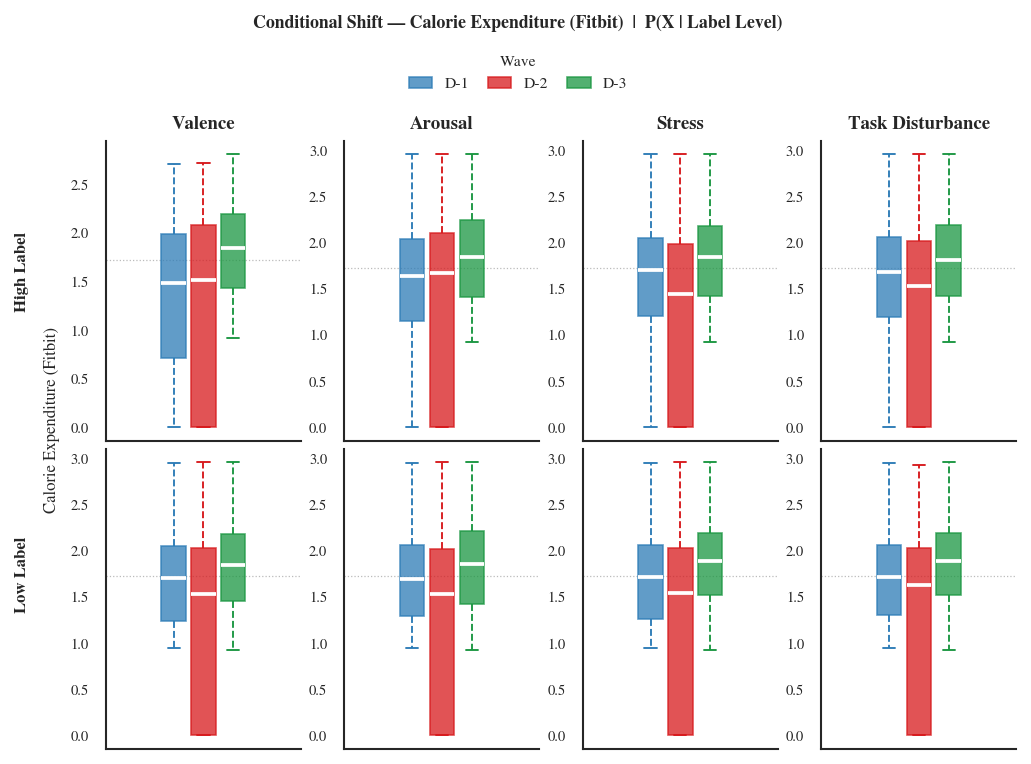

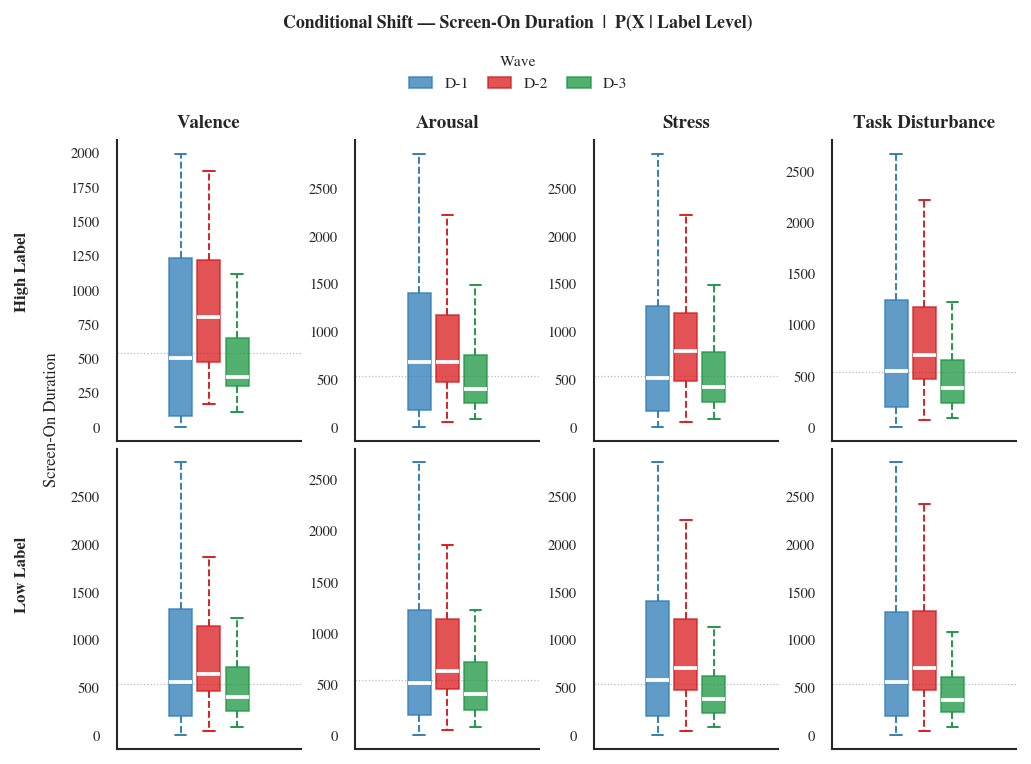

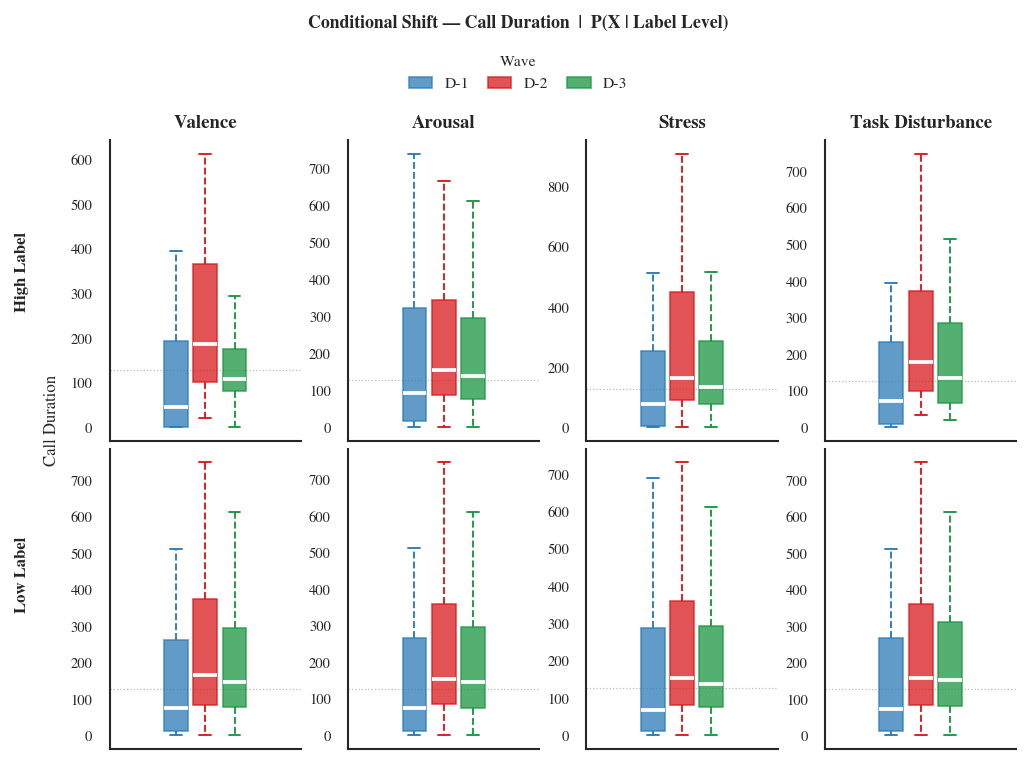

In [13]:
# ── Conditional Shift — Boxplot Version ──────────────────────────────────────
# Same P(X|Y) logic as the KDE version; boxplots show distributional spread.
_COND_FEATURES_BOX = [
    "Sleep#Duration",
    "Fitbitcalorie#VAL",
    "SCR_EVENT#DSC=ON",
    "CALL_DUR#VAL",
]
_FEATURE_DISPLAY_BOX = {
    "Sleep#Duration"   : "Sleep Duration",
    "Fitbitcalorie#VAL": "Calorie Expenditure (Fitbit)",
    "SCR_EVENT#DSC=ON" : "Screen-On Duration",
    "CALL_DUR#VAL"     : "Call Duration",
}
_BOX_WIDTH   = 0.18
_BOX_OFFSETS = {"D-1": -0.22, "D-2": 0.0, "D-3": 0.22}


for _feature in _COND_FEATURES_BOX:
    if _feature not in df_X_combined.columns:
        print(f"  Skipping {_feature!r} — column not found")
        continue

    feat_df = (
        df_X_combined[["META#dataset", "PIF#participantID", _feature]]
        .dropna()
        .groupby(["META#dataset", "PIF#participantID"])[_feature]
        .mean()
        .reset_index()
        .rename(columns={"META#dataset": "Wave", "PIF#participantID": "Pcode", _feature: "feat_val"})
    )
    p01, p99 = feat_df["feat_val"].quantile([0.01, 0.99])
    feat_df["feat_val"] = feat_df["feat_val"].clip(p01, p99)

    fig, axes = plt.subplots(2, 4, figsize=(6.75, 4.5), sharey=False, sharex=False)
    fig.subplots_adjust(hspace=0.40, wspace=0.25)
    feat_display = _FEATURE_DISPLAY_BOX.get(_feature, _feature)

    for ax_i, lbl in enumerate(SHARED_LABELS):
        groups = _split_label_groups(lbl, esm_by_wave, WAVE_KEYS)
        if groups is None:
            continue
        high_pcodes, low_pcodes = groups

        for row_i, (pcode_set, group_name) in enumerate([
            (high_pcodes, "High Label"),
            (low_pcodes,  "Low Label"),
        ]):
            ax = axes[row_i, ax_i]

            for wk in WAVE_KEYS:
                vals = feat_df[(feat_df["Wave"] == wk) & feat_df["Pcode"].isin(pcode_set)]["feat_val"].dropna().values

                if len(vals) < 5:
                    continue

                ax.boxplot(
                    vals,
                    positions=[_BOX_OFFSETS[wk]],
                    widths=_BOX_WIDTH,
                    patch_artist=True,
                    notch=False,
                    showfliers=False,
                    medianprops=dict(color="white", linewidth=1.8),
                    boxprops=dict(facecolor=COLORS[wk], alpha=0.75, linewidth=0.8, edgecolor=COLORS[wk]),
                    whiskerprops=dict(color=COLORS[wk], linewidth=0.9, linestyle="--"),
                    capprops=dict(color=COLORS[wk], linewidth=0.9),
                )

            ax.spines[["top", "right"]].set_visible(False)
            ax.set_xticks([])
            ax.tick_params(labelsize=7)
            ax.axhline(feat_df["feat_val"].median(), color="#BBBBBB", lw=0.6, ls=":", zorder=0)
            if row_i == 0:
                ax.set_title(lbl, fontsize=9, fontweight="bold", pad=6)

    for row_i, row_label in enumerate(["High Label", "Low Label"]):
        mid_y = (axes[row_i, 0].get_position().y0 + axes[row_i, 0].get_position().y1) / 2
        fig.text(0.01, mid_y, row_label, ha="center", va="center", fontsize=8, fontweight="bold", rotation=90)

    fig.text(0.04, 0.5, feat_display, ha="center", va="center", fontsize=8, rotation=90)

    legend_handles = [
        mpatches.Patch(facecolor=COLORS[wk], alpha=0.75, edgecolor=COLORS[wk], label=wk)
        for wk in WAVE_KEYS
    ]
    fig.legend(
        handles=legend_handles,
        title="Wave",
        title_fontsize=7.5,
        fontsize=7.5,
        loc="upper center",
        ncol=len(WAVE_KEYS),
        bbox_to_anchor=(0.5, 1.06),
        frameon=False,
        handlelength=1.5,
        columnspacing=1.2,
    )

    fig.suptitle(f"Conditional Shift — {feat_display}  |  P(X | Label Level)", fontsize=8.5, fontweight="bold", y=1.10)
    plt.tight_layout(pad=0.4, rect=[0.05, 0, 1, 1])
    plt.show()